In [6]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud

In [7]:
import nltk

nltk.download("stopwords")
nltk.download("vader_lexicon")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [8]:
data = {
    "Review": [
        "The movie was amazing with excellent acting.",
        "The storyline was boring and predictable.",
        "Fantastic music and wonderful direction.",
        "The movie was too long and slow.",
        "Great performances by all actors.",
        "Poor screenplay and weak acting.",
        "Average movie with decent entertainment.",
        "The visual effects were outstanding.",
        "Waste of time and money.",
        "The ending was emotional and satisfying."
    ]
}

df = pd.DataFrame(data)

print("Movie Reviews Dataset")
print(df)

Movie Reviews Dataset
                                         Review
0  The movie was amazing with excellent acting.
1     The storyline was boring and predictable.
2      Fantastic music and wonderful direction.
3              The movie was too long and slow.
4             Great performances by all actors.
5              Poor screenplay and weak acting.
6      Average movie with decent entertainment.
7          The visual effects were outstanding.
8                      Waste of time and money.
9      The ending was emotional and satisfying.


In [9]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["Cleaned_Review"] = df["Review"].apply(clean_text)

print(df[["Review","Cleaned_Review"]])

                                         Review  \
0  The movie was amazing with excellent acting.   
1     The storyline was boring and predictable.   
2      Fantastic music and wonderful direction.   
3              The movie was too long and slow.   
4             Great performances by all actors.   
5              Poor screenplay and weak acting.   
6      Average movie with decent entertainment.   
7          The visual effects were outstanding.   
8                      Waste of time and money.   
9      The ending was emotional and satisfying.   

                        Cleaned_Review  
0       movie amazing excellent acting  
1         storyline boring predictable  
2  fantastic music wonderful direction  
3                      movie long slow  
4            great performances actors  
5          poor screenplay weak acting  
6   average movie decent entertainment  
7           visual effects outstanding  
8                     waste time money  
9          ending emotional 

In [10]:
sia = SentimentIntensityAnalyzer()

def sentiment(review):

    score = sia.polarity_scores(review)["compound"]

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Review"].apply(sentiment)

print(df[["Review","Sentiment"]])

                                         Review Sentiment
0  The movie was amazing with excellent acting.  Positive
1     The storyline was boring and predictable.  Negative
2      Fantastic music and wonderful direction.  Positive
3              The movie was too long and slow.   Neutral
4             Great performances by all actors.  Positive
5              Poor screenplay and weak acting.  Negative
6      Average movie with decent entertainment.  Positive
7          The visual effects were outstanding.  Positive
8                      Waste of time and money.  Negative
9      The ending was emotional and satisfying.  Positive


In [11]:
all_words = " ".join(df["Cleaned_Review"])

word_list = all_words.split()

word_freq = Counter(word_list)

print("Top 10 Common Words")

print(word_freq.most_common(10))

Top 10 Common Words
[('movie', 3), ('acting', 2), ('amazing', 1), ('excellent', 1), ('storyline', 1), ('boring', 1), ('predictable', 1), ('fantastic', 1), ('music', 1), ('wonderful', 1)]


In [12]:
negative_reviews = df[df["Sentiment"]=="Negative"]

negative_words = " ".join(negative_reviews["Cleaned_Review"])

complaints = Counter(negative_words.split())

print("Common Negative Opinions")

print(complaints.most_common(10))

Common Negative Opinions
[('storyline', 1), ('boring', 1), ('predictable', 1), ('poor', 1), ('screenplay', 1), ('weak', 1), ('acting', 1), ('waste', 1), ('time', 1), ('money', 1)]


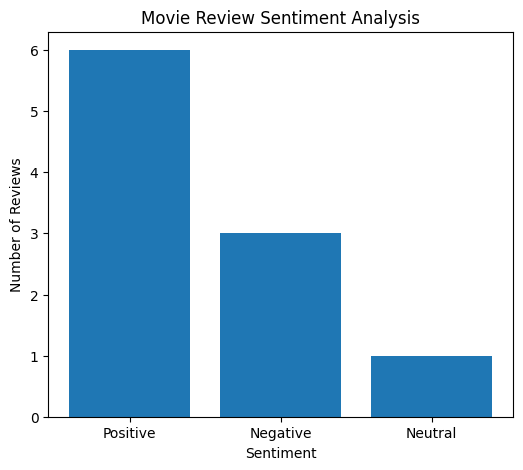

In [13]:
sentiment_count = df["Sentiment"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(sentiment_count.index, sentiment_count.values)

plt.title("Movie Review Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Reviews")

plt.show()

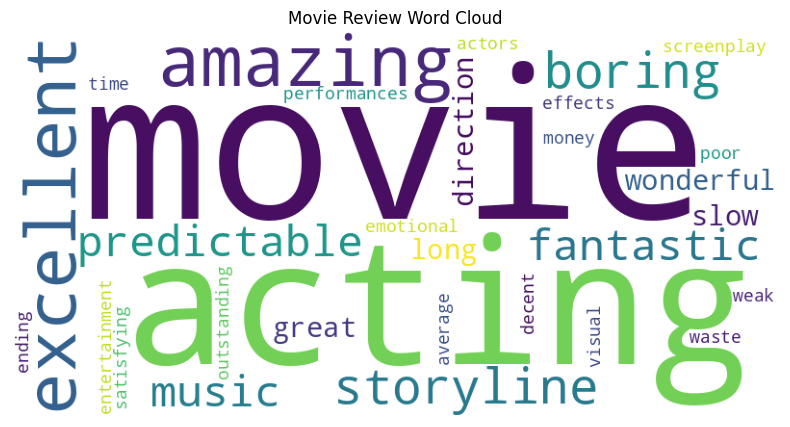

In [14]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Movie Review Word Cloud")

plt.show()

In [15]:
positive = len(df[df["Sentiment"]=="Positive"])
negative = len(df[df["Sentiment"]=="Negative"])
neutral = len(df[df["Sentiment"]=="Neutral"])

print("Movie Review Analysis Report")
print("-----------------------------")

print("Positive Reviews :", positive)
print("Negative Reviews :", negative)
print("Neutral Reviews :", neutral)

print("\nAudience Liked")
print("- Acting")
print("- Music")
print("- Direction")
print("- Visual Effects")

print("\nAudience Disliked")
print("- Weak Storyline")
print("- Slow Pace")
print("- Poor Screenplay")
print("- Weak Acting")

print("\nRecommendation")
print("Improve story quality, screenplay, and pacing while maintaining strong acting and visual effects.")

Movie Review Analysis Report
-----------------------------
Positive Reviews : 6
Negative Reviews : 3
Neutral Reviews : 1

Audience Liked
- Acting
- Music
- Direction
- Visual Effects

Audience Disliked
- Weak Storyline
- Slow Pace
- Poor Screenplay
- Weak Acting

Recommendation
Improve story quality, screenplay, and pacing while maintaining strong acting and visual effects.
